# PM2.5 Prediction Using Neural Network Model (scikit-learn)

**Optimized with Optuna + TimeSeriesSplit Cross-Validation**

## 1. Setup & Data Loading

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import TransformedTargetRegressor
import joblib
import time

# For hyperparameter tuning
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

# Setup paths
notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    base_dir = notebook_dir.parent
else:
    base_dir = notebook_dir

output_dir = base_dir / 'preprocessed_data'
model_dir = base_dir / 'models'
model_dir.mkdir(exist_ok=True)

print(f"Base directory: {base_dir}")
print(f"Data directory: {output_dir}")
print(f"Model directory: {model_dir}")

Base directory: c:\Users\user\Desktop\3Y\S02\GP\project\pm25-air-quality
Data directory: c:\Users\user\Desktop\3Y\S02\GP\project\pm25-air-quality\preprocessed_data
Model directory: c:\Users\user\Desktop\3Y\S02\GP\project\pm25-air-quality\models


In [57]:
# Load preprocessed data
X_train = pd.read_csv(output_dir / 'X_train.csv')
y_train = pd.read_csv(output_dir / 'y_train.csv').squeeze()
X_test = pd.read_csv(output_dir / 'X_test.csv')
y_test = pd.read_csv(output_dir / 'y_test.csv').squeeze()


# Enforce final optimized feature set
final_features = [
    'latitude', 'longitude', 'year',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'temperature_celsius', 'pressure_mb', 'wind_u', 'wind_v', 'wind_magnitude',
    'NO2',
     'CO', 'O3', 
     'AOD', 
    'pollution_index',
    #'pm25_lag1', 
    'temp_lag1', 'pollution_lag1',
    'aod_pollution_interaction', 'temp_pollution_interaction',
    'pressure_pollution_interaction', 'temp_pressure_interaction',
    'building_density', 'road_density_km', 'industrial_presence', 
        'green_space_fraction', 'relative_humidity',

]

# Filter to available features to avoid potential missing column errors
final_features = [f for f in final_features if f in X_train.columns]


X_train = X_train[final_features]
X_test = X_test[final_features]


print(f"Training set:   {X_train.shape[0]:>6,} samples, {X_train.shape[1]} features")
print(f"Test set:       {X_test.shape[0]:>6,} samples, {X_test.shape[1]} features")

print(f"\nFeatures: {list(X_train.columns)}")

# Data verification
print(f"\n{'='*80}")
print("DATA VERIFICATION")
print(f"{'='*80}")

print(f"\nFeature scaling check:")
print(f"  X_train mean: {X_train.mean().mean():.4f}, std: {X_train.std().mean():.4f}")
print(f"  X_test mean:  {X_test.mean().mean():.4f}, std: {X_test.std().mean():.4f}")

print(f"\nMissing values check:")
print(f"  X_train: {X_train.isnull().sum().sum()} missing")
print(f"  X_test:  {X_test.isnull().sum().sum()} missing")
print(f"  y_train: {y_train.isnull().sum()} missing")
print(f"  y_test:  {y_test.isnull().sum()} missing")

print(f"\nTarget (pm25) statistics:")
print(f"  Train — mean: {y_train.mean():.2f}, std: {y_train.std():.2f}, range: [{y_train.min():.2f}, {y_train.max():.2f}]")
print(f"  Test  — mean: {y_test.mean():.2f}, std: {y_test.std():.2f}, range: [{y_test.min():.2f}, {y_test.max():.2f}]")


Training set:   33,069 samples, 28 features
Test set:        7,927 samples, 28 features

Features: ['latitude', 'longitude', 'year', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'temperature_celsius', 'pressure_mb', 'wind_u', 'wind_v', 'wind_magnitude', 'NO2', 'CO', 'O3', 'AOD', 'pollution_index', 'temp_lag1', 'pollution_lag1', 'aod_pollution_interaction', 'temp_pollution_interaction', 'pressure_pollution_interaction', 'temp_pressure_interaction', 'building_density', 'road_density_km', 'industrial_presence', 'green_space_fraction', 'relative_humidity']

DATA VERIFICATION

Feature scaling check:
  X_train mean: 73.6911, std: 1.1248
  X_test mean:  73.9518, std: 1.0880

Missing values check:
  X_train: 0 missing
  X_test:  0 missing
  y_train: 0 missing
  y_test:  0 missing

Target (pm25) statistics:
  Train — mean: 9.37, std: 16.70, range: [0.00, 1000.00]
  Test  — mean: 10.04, std: 7.28, range: [0.00, 72.88]


``Note:`` 
- Outliers should be handled or removed in preprocessing for better model performance(we'll keep them for now but more investigation regarding them is needed)
- Selected only the needed features but this should be moved to the preprocessing notebook

## 2. Evaluation Metrics Function

In [58]:
def compute_metrics(y_true, y_pred, set_name=""):
    """Compute comprehensive regression metrics."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    
    metrics = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
    }
    
    if set_name:
        print(f"{set_name} Set:")
        print(f"  MSE:  {mse:.4f}")
        print(f"  RMSE: {rmse:.4f} μg/m³")
        print(f"  MAE:  {mae:.4f} μg/m³")
        print(f"  R²:   {r2:.4f}")
    
    return metrics

print("Metrics function defined")

Metrics function defined


- This is just a fast one to select K

In [59]:
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.neural_network import MLPRegressor
# from sklearn.feature_selection import SelectKBest, mutual_info_regression

# # Define the pipeline
# pipeline_filter = Pipeline([
#     ('feature_selection', SelectKBest(score_func=mutual_info_regression, k=24)), 
#     ('mlp', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))
# ])

# # 1. You MUST fit the pipeline to your training data first
# # (Assuming your data variables are named X_train and y_train)
# pipeline_filter.fit(X_train, y_train)

# # 2. Access the fitted feature selection step
# selector_step = pipeline_filter.named_steps['feature_selection']


# final_feature_names = selector_step.get_feature_names_out(X_train.columns)
# print("Names of selected features:", final_feature_names)

# new_final_features=final_feature_names


In [60]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.model_selection import GridSearchCV

# 1. Define the base pipeline WITHOUT specifying k
pipeline_filter = Pipeline([
    ('feature_selection', SelectKBest(score_func=mutual_info_regression)), 
    ('mlp', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))
])

# 2. Define the grid of parameters you want to test
# Syntax: step_name + '__' + parameter_name
param_grid = {
    'feature_selection__k': [24, 25, 26, 27, 28] 
}

# 3. Setup GridSearchCV
# cv=5 means 5-fold cross validation. 
# n_jobs=-1 uses all CPU cores to speed up training.
grid_search = GridSearchCV(
    estimator=pipeline_filter, 
    param_grid=param_grid, 
    cv=5, 
    scoring='r2', # You can change this to 'neg_mean_squared_error' if you prefer MSE
    n_jobs=-1,
    verbose=1 # Prints progress
)

# 4. Fit the GridSearch to find the best K
print("Searching for the best K...")
grid_search.fit(X_train, y_train)

# 5. Output the best results
best_k = grid_search.best_params_['feature_selection__k']
print(f"\nBest K found: {best_k}")
print(f"Best R2 Score: {grid_search.best_score_:.4f}")

# 6. Extract the features chosen by the BEST model
best_pipeline = grid_search.best_estimator_
selector_step = best_pipeline.named_steps['feature_selection']

# Get the names of the final selected features
final_feature_names = selector_step.get_feature_names_out(X_train.columns)
print("\nNames of final selected features:")
print(final_feature_names)

new_final_features = final_feature_names


Searching for the best K...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best K found: 26
Best R2 Score: 0.0366

Names of final selected features:
['latitude' 'longitude' 'year' 'month_sin' 'month_cos'
 'temperature_celsius' 'pressure_mb' 'wind_u' 'wind_v' 'wind_magnitude'
 'NO2' 'CO' 'O3' 'AOD' 'pollution_index' 'temp_lag1' 'pollution_lag1'
 'aod_pollution_interaction' 'temp_pollution_interaction'
 'pressure_pollution_interaction' 'temp_pressure_interaction'
 'building_density' 'road_density_km' 'industrial_presence'
 'green_space_fraction' 'relative_humidity']


In [61]:
print(new_final_features)
print("#######################")
print(set(final_features)-set(new_final_features))
final_features=new_final_features

['latitude' 'longitude' 'year' 'month_sin' 'month_cos'
 'temperature_celsius' 'pressure_mb' 'wind_u' 'wind_v' 'wind_magnitude'
 'NO2' 'CO' 'O3' 'AOD' 'pollution_index' 'temp_lag1' 'pollution_lag1'
 'aod_pollution_interaction' 'temp_pollution_interaction'
 'pressure_pollution_interaction' 'temp_pressure_interaction'
 'building_density' 'road_density_km' 'industrial_presence'
 'green_space_fraction' 'relative_humidity']
#######################
{'dow_cos', 'dow_sin'}


## 3. Hyperparameter Tuning with Optuna + TimeSeriesSplit

We'll use Optuna to find optimal hyperparameters using TimeSeriesSplit cross-validation on the training set.

In [67]:
def objective(trial):
   # Suggest hyperparameters
    hidden_layer_1 = trial.suggest_int('hidden_layer_1', 64, 256, step=32)
    hidden_layer_2 = trial.suggest_int('hidden_layer_2', 32, 128, step=16)
    hidden_layer_3 = trial.suggest_int('hidden_layer_3', 16, 64, step=16)
    
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    alpha = trial.suggest_float('alpha', 1e-5, 1e-2, log=True)
    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])

    optuna_base_model = MLPRegressor(
        hidden_layer_sizes=(hidden_layer_1, hidden_layer_2, hidden_layer_3),
        activation=activation,
        solver='adam',
        alpha=alpha,
        batch_size=batch_size,
        learning_rate='adaptive',
        learning_rate_init=learning_rate_init,
        max_iter=300,  # Reduced for faster tuning
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        shuffle=False,
        random_state=42,
        verbose=False
    )
    
    # model = TransformedTargetRegressor(
    # regressor=optuna_base_model,
    # func=np.log1p,         # log(1 + y) transform before training
    # inverse_func=np.expm1  # exp(y) - 1 transform after prediction
    # )
    model=optuna_base_model
    tscv = TimeSeriesSplit(n_splits=5)
    
    # Dictionaries/Lists to track metrics for THIS specific trial
    fold_rmses, fold_maes, fold_r2s = [], [], []
    train_sizes, val_sizes = [], []

    for train_idx, val_idx in tscv.split(X_train):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Train your MLPRegressor here...
        model.fit(X_fold_train, y_fold_train)
        val_pred = model.predict(X_fold_val)
        
        # Calculate your metrics
        fold_rmse = np.sqrt(mean_squared_error(y_fold_val, val_pred))
        fold_mae = mean_absolute_error(y_fold_val, val_pred)
        fold_r2 = r2_score(y_fold_val, val_pred)
        
        # Append to lists
        fold_rmses.append(fold_rmse)
        fold_maes.append(fold_mae)
        fold_r2s.append(fold_r2)
        train_sizes.append(len(train_idx))
        val_sizes.append(len(val_idx))

    # 2. SAVE the lists to the trial attributes
    trial.set_user_attr("fold_rmse", fold_rmses)
    trial.set_user_attr("fold_mae", fold_maes)
    trial.set_user_attr("fold_r2", fold_r2s)
    trial.set_user_attr("train_sizes", train_sizes)
    trial.set_user_attr("val_sizes", val_sizes)

    # 3. Return the mean metric for Optuna to minimize
    return np.mean(fold_rmses)

In [68]:
# Create and run Optuna study
print(f"{'='*80}")
print("HYPERPARAMETER OPTIMIZATION WITH OPTUNA")
print(f"{'='*80}")
print(f"\nSearching for optimal hyperparameters...")
print(f"This may take time depending on n_trials\n")

# Create study
study = optuna.create_study(
    direction='minimize',  # Minimize RMSE
    study_name='mlp_pm25_optimization',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Run optimization
N_TRIALS = 10
start_time = time.time()

study.optimize(
    objective, 
    n_trials=N_TRIALS,
    show_progress_bar=True,
    n_jobs=1  
)

elapsed = time.time() - start_time
print(f"\n{'='*80}")
print(f"OPTIMIZATION COMPLETE")
print(f"{'='*80}")
print(f"Time elapsed: {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Number of trials: {len(study.trials)}")

# Get the best trial
best_trial = study.best_trial

print(f"\nBest trial:")
print(f"  Value (Mean CV RMSE): {best_trial.value:.4f} μg/m³")
print(f"  Params:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

# Save study
joblib.dump(study, model_dir / 'optuna_study.pkl')
print(f"\nStudy saved to {model_dir / 'optuna_study.pkl'}")

print(f"\n{'='*80}")
print("BEST HYPERPARAMETERS CROSS-VALIDATION BREAKDOWN")
print(f"{'='*80}")

# Extract the saved custom attributes from the best trial
best_rmses = best_trial.user_attrs["fold_rmse"]
best_maes = best_trial.user_attrs["fold_mae"]
best_r2s = best_trial.user_attrs["fold_r2"]
train_sizes = best_trial.user_attrs["train_sizes"]
val_sizes = best_trial.user_attrs["val_sizes"]

# Print fold-by-fold breakdown
cv_results = []
for i in range(len(best_rmses)):
    print(f"Fold {i+1}:")
    print(f"  Train: {train_sizes[i]:>6} samples")
    print(f"  Val:   {val_sizes[i]:>6} samples | R²={best_r2s[i]:>6.4f} | RMSE={best_rmses[i]:>7.4f} | MAE={best_maes[i]:>6.4f}\n")
    
    cv_results.append({
        'fold': i+1,
        'val_r2': best_r2s[i],
        'val_rmse': best_rmses[i],
        'val_mae': best_maes[i]
    })

# Save to CSV
cv_df = pd.DataFrame(cv_results)
print(f"\nValidation Metrics (Mean ± Std):")
print(f"  R²:   {cv_df['val_r2'].mean():.4f} ± {cv_df['val_r2'].std():.4f}")
print(f"  RMSE: {cv_df['val_rmse'].mean():.4f} ± {cv_df['val_rmse'].std():.4f} μg/m³")
print(f"  MAE:  {cv_df['val_mae'].mean():.4f} ± {cv_df['val_mae'].std():.4f} μg/m³")

cv_df.to_csv(model_dir / 'cv_results.csv', index=False)
print(f"\nCV results saved")

[I 2026-04-26 23:54:01,179] A new study created in memory with name: mlp_pm25_optimization


HYPERPARAMETER OPTIMIZATION WITH OPTUNA

Searching for optimal hyperparameters...
This may take time depending on n_trials



Best trial: 0. Best value: 14.6424:  10%|█         | 1/10 [01:58<17:50, 118.94s/it]

[I 2026-04-26 23:56:00,117] Trial 0 finished with value: 14.642372275151658 and parameters: {'hidden_layer_1': 128, 'hidden_layer_2': 128, 'hidden_layer_3': 48, 'activation': 'relu', 'alpha': 2.9375384576328295e-05, 'learning_rate_init': 0.00013066739238053285, 'batch_size': 64}. Best is trial 0 with value: 14.642372275151658.


Best trial: 1. Best value: 14.5781:  20%|██        | 2/10 [09:58<44:08, 331.10s/it]

...

[I 2026-04-27 00:19:21,855] Trial 7 finished with value: 15.021516815639306 and parameters: {'hidden_layer_1': 224, 'hidden_layer_2': 48, 'hidden_layer_3': 16, 'activation': 'relu', 'alpha': 0.0015382308040279, 'learning_rate_init': 0.0034877126245459306, 'batch_size': 128}. Best is trial 1 with value: 14.578063304168236.


Best trial: 1. Best value: 14.5781:  90%|█████████ | 9/10 [26:30<02:18, 138.76s/it]

[I 2026-04-27 00:20:31,207] Trial 8 finished with value: 14.667260881583791 and parameters: {'hidden_layer_1': 256, 'hidden_layer_2': 96, 'hidden_layer_3': 32, 'activation': 'tanh', 'alpha': 9.452571391072311e-05, 'learning_rate_init': 0.002878805718308925, 'batch_size': 128}. Best is trial 1 with value: 14.578063304168236.


Best trial: 1. Best value: 14.5781: 100%|██████████| 10/10 [27:16<00:00, 163.64s/it]

[I 2026-04-27 00:21:17,554] Trial 9 finished with value: 14.676928589059383 and parameters: {'hidden_layer_1': 64, 'hidden_layer_2': 96, 'hidden_layer_3': 64, 'activation': 'tanh', 'alpha': 0.00030296104428212476, 'learning_rate_init': 0.0011103647313054626, 'batch_size': 64}. Best is trial 1 with value: 14.578063304168236.

OPTIMIZATION COMPLETE
Time elapsed: 1636.4s (27.3 min)
Number of trials: 10

Best trial:
  Value (Mean CV RMSE): 14.5781 μg/m³
  Params:
    hidden_layer_1: 64
    hidden_layer_2: 128
    hidden_layer_3: 64
    activation: relu
    alpha: 3.5498788321965036e-05
    learning_rate_init: 0.0004059611610484307
    batch_size: 64

Study saved to c:\Users\user\Desktop\3Y\S02\GP\project\pm25-air-quality\models\optuna_study.pkl

BEST HYPERPARAMETERS CROSS-VALIDATION BREAKDOWN
Fold 1:
  Train:   5514 samples
  Val:     5511 samples | R²=-0.0535 | RMSE= 7.8781 | MAE=4.8626

Fold 2:
  Train:  11025 samples
  Val:     5511 samples | R²=0.0068 | RMSE=32.3332 | MAE=5.8227

Fold 

## 4. Train Final Model with Best Hyperparameters

## This uses optuna results

- Run this to load the optuna results

In [69]:
study = joblib.load('../models/optuna_study.pkl')
best_params = study.best_params 


In [70]:
# Extract best hyperparameters
best_params = study.best_params

print(f"{'='*80}")
print("TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
print(f"{'='*80}")

# Create final model
base_model = MLPRegressor(
    hidden_layer_sizes=(
        best_params['hidden_layer_1'],
        best_params['hidden_layer_2'],
        best_params['hidden_layer_3']
    ),
    activation=best_params['activation'],
    solver='adam',
    alpha=best_params['alpha'],
    batch_size=best_params['batch_size'],
    learning_rate='adaptive',
    learning_rate_init=best_params['learning_rate_init'],
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    tol=1e-5,
    shuffle=False,
    random_state=42,
    verbose=True
)
# final_model = TransformedTargetRegressor(
#     regressor=base_model,
#     func=np.log1p,         # log(1 + y) transform before training
#     inverse_func=np.expm1  # exp(y) - 1 transform after prediction
# )
final_model=base_model

print(f"\nModel architecture:")
print(f"  Hidden layers: ({best_params['hidden_layer_1']}, {best_params['hidden_layer_2']}, {best_params['hidden_layer_3']})")
print(f"  Activation: {best_params['activation']}")
print(f"  Alpha (L2): {best_params['alpha']:.6f}")
print(f"  Learning rate: {best_params['learning_rate_init']:.6f}")
print(f"  Batch size: {best_params['batch_size']}")

print(f"\n{'='*60}")
print("Starting training on full training set...")
print(f"{'='*60}\n")

start_time = time.time()
final_model.fit(X_train, y_train)
elapsed = time.time() - start_time

print(f"\n{'='*60}")
print(f"Training complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Iterations: {final_model.n_iter_}")
print(f"Best validation score: {final_model.best_validation_score_:.4f}")
print(f"Final training loss: {final_model.loss_:.6f}")
print(f"{'='*60}")


TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS

Model architecture:
  Hidden layers: (64, 128, 64)
  Activation: relu
  Alpha (L2): 0.000035
  Learning rate: 0.000406
  Batch size: 64

Starting training on full training set...

Iteration 1, loss = 150.58184758
Validation score: -0.012787
Iteration 2, loss = 113.33096887
Validation score: -0.000587
Iteration 3, loss = 113.78688916
Validation score: -0.019640
Iteration 4, loss = 114.03905323
Validation score: -0.020475
Iteration 5, loss = 113.84638039
Validation score: -0.019030
Iteration 6, loss = 113.26106352
Validation score: -0.016000
Iteration 7, loss = 113.04649211
Validation score: -0.005867
Iteration 8, loss = 112.72932223
Validation score: 0.000696
Iteration 9, loss = 112.46078301
Validation score: 0.004650
Iteration 10, loss = 112.15203992
Validation score: 0.005559
Iteration 11, loss = 111.94195963
Validation score: 0.006353
Iteration 12, loss = 111.62574412
Validation score: 0.006173
Iteration 13, loss = 111.41518324
Validati

## 5. Model Evaluation on Both Splits

In [71]:
#Generate predictions
train_pred = final_model.predict(X_train)
test_pred = final_model.predict(X_test)

print(f"{'='*80}")
print("MODEL EVALUATION RESULTS")
print(f"{'='*80}\n")

results = {}
results['Train'] = compute_metrics(y_train.values, train_pred, "Train")
print()
results['Test'] = compute_metrics(y_test.values, test_pred, "Test")

results_df = pd.DataFrame(results).T
print(f"\n{'='*80}")
print("\nSummary Table:")
print(results_df.to_string())
print(f"\n{'='*80}")



MODEL EVALUATION RESULTS

Train Set:
  MSE:  273.7818
  RMSE: 16.5464 μg/m³
  MAE:  5.0577 μg/m³
  R²:   0.0188

Test Set:
  MSE:  45.6306
  RMSE: 6.7550 μg/m³
  MAE:  4.6600 μg/m³
  R²:   0.1389


Summary Table:
              MSE       RMSE       MAE        R²
Train  273.781811  16.546353  5.057673  0.018773
Test    45.630621   6.755044  4.659964  0.138870



## 6. Prediction Visualizations

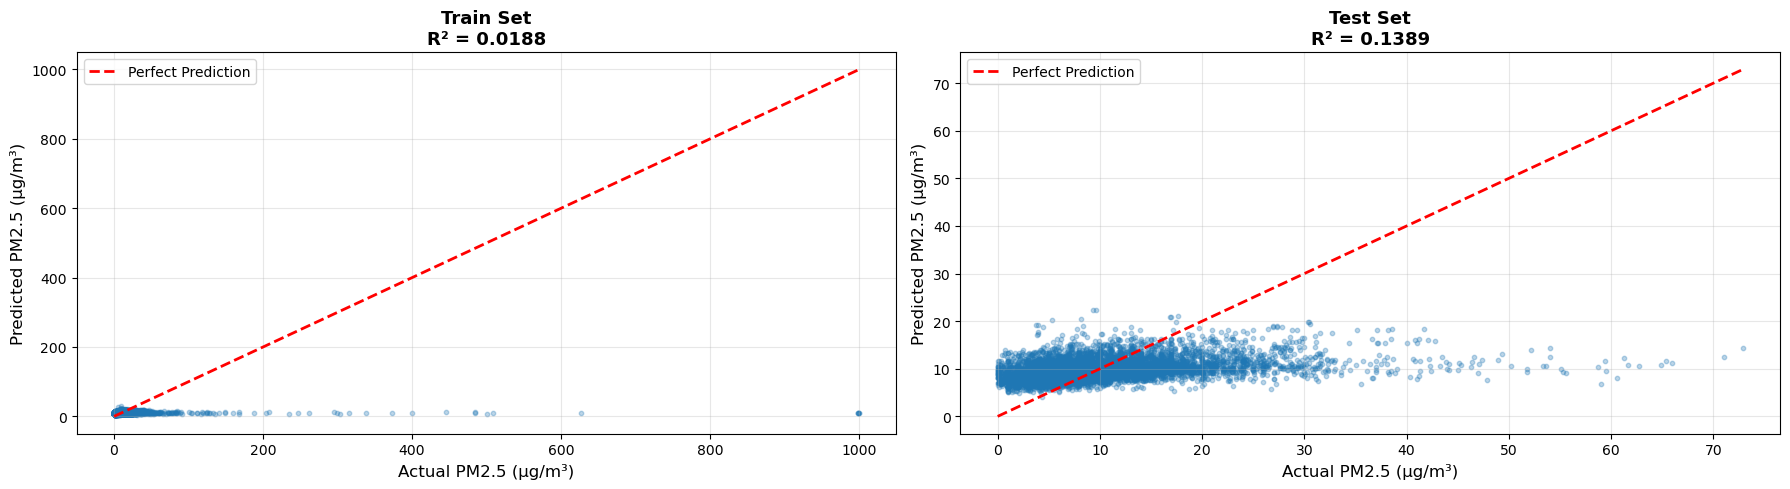

In [72]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for idx, (name, y_true, y_pred) in enumerate([
    ('Train', y_train.values, train_pred),
    ('Test', y_test.values, test_pred)
]):
    ax = axes[idx]
    ax.scatter(y_true, y_pred, alpha=0.3, s=10)
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual PM2.5 (μg/m³)', fontsize=12)
    ax.set_ylabel('Predicted PM2.5 (μg/m³)', fontsize=12)
    ax.set_title(f'{name} Set\nR² = {results[name]["R²"]:.4f}', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(model_dir / 'predictions_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


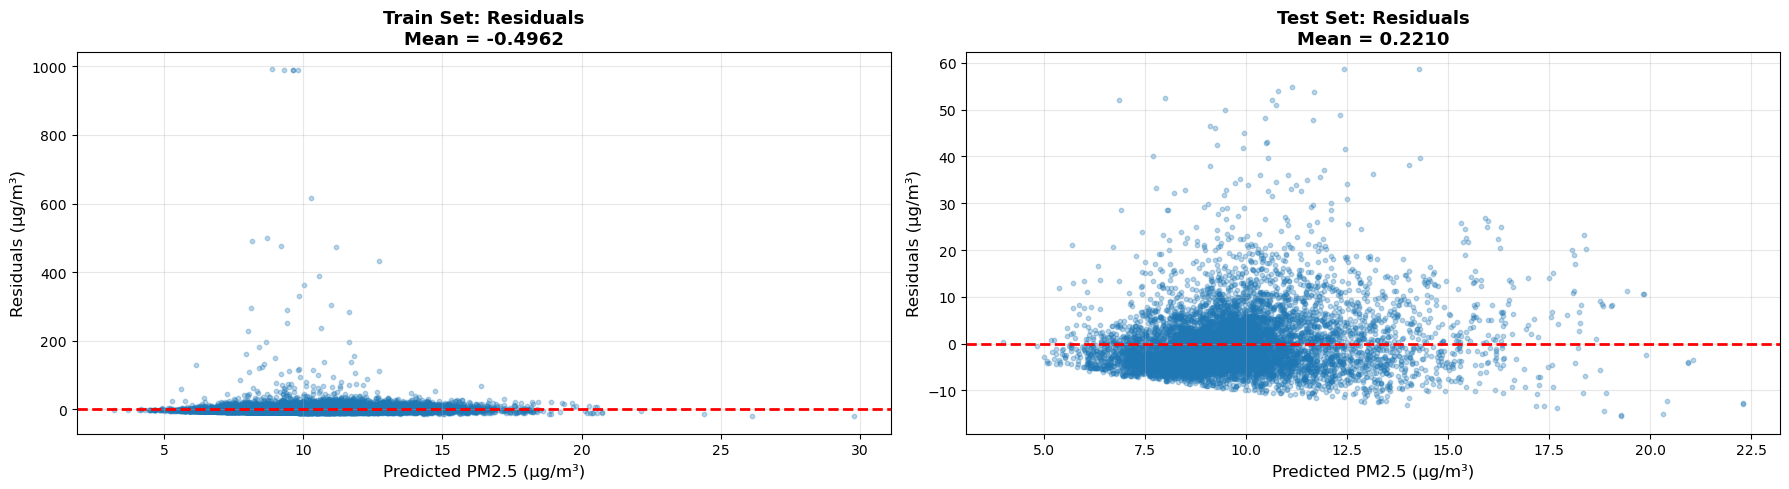

In [73]:
# Residual plots
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for idx, (name, y_true, y_pred) in enumerate([
    ('Train', y_train.values, train_pred),
    ('Test', y_test.values, test_pred)
]):
    ax = axes[idx]
    residuals = y_true - y_pred
    
    ax.scatter(y_pred, residuals, alpha=0.3, s=10)
    ax.axhline(y=0, color='r', linestyle='--', lw=2)
    
    ax.set_xlabel('Predicted PM2.5 (μg/m³)', fontsize=12)
    ax.set_ylabel('Residuals (μg/m³)', fontsize=12)
    ax.set_title(f'{name} Set: Residuals\nMean = {residuals.mean():.4f}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(model_dir / 'residuals.png', dpi=150, bbox_inches='tight')
plt.show()


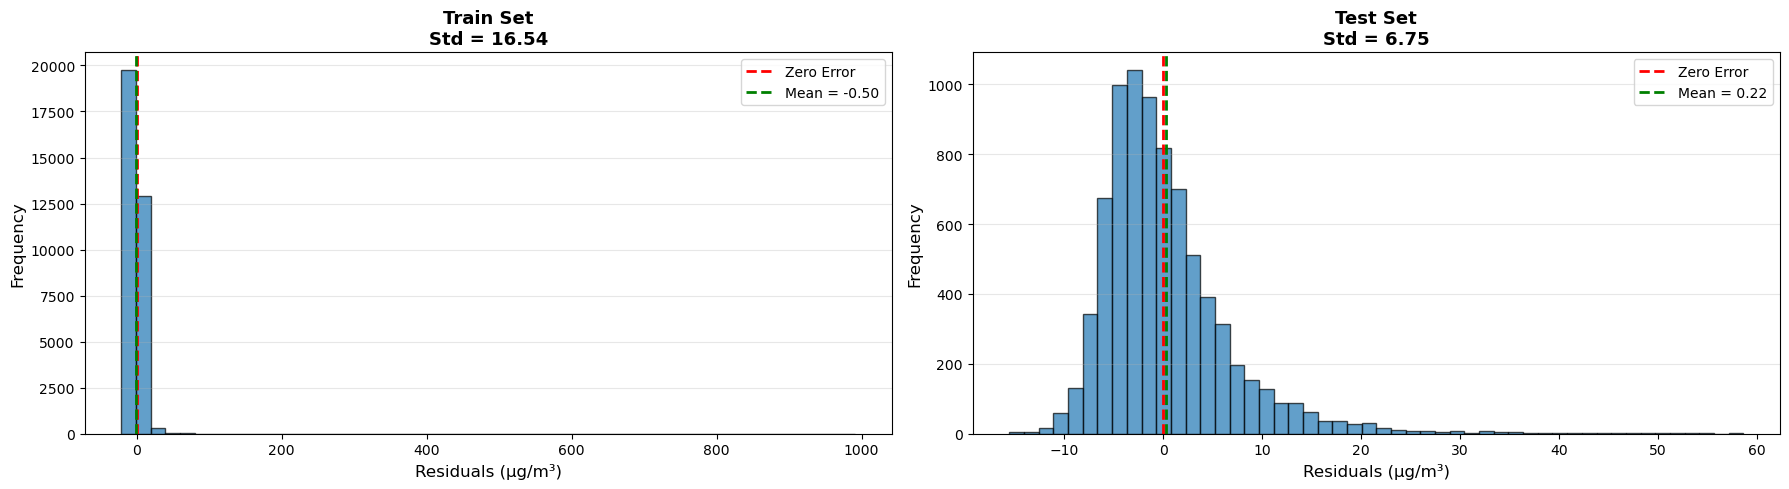

In [74]:
# Error distribution
fig, axes = plt.subplots(1,2, figsize=(18, 5))

for idx, (name, y_true, y_pred) in enumerate([
    ('Train', y_train.values, train_pred),
    ('Test', y_test.values, test_pred)
]):
    ax = axes[idx]
    residuals = y_true - y_pred
    
    ax.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
    ax.axvline(x=residuals.mean(), color='g', linestyle='--', lw=2, label=f'Mean = {residuals.mean():.2f}')
    
    ax.set_xlabel('Residuals (μg/m³)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{name} Set\nStd = {residuals.std():.2f}', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(model_dir / 'error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


# Feature importance

Calculating Permutation Feature Importance (this might take a few seconds)...


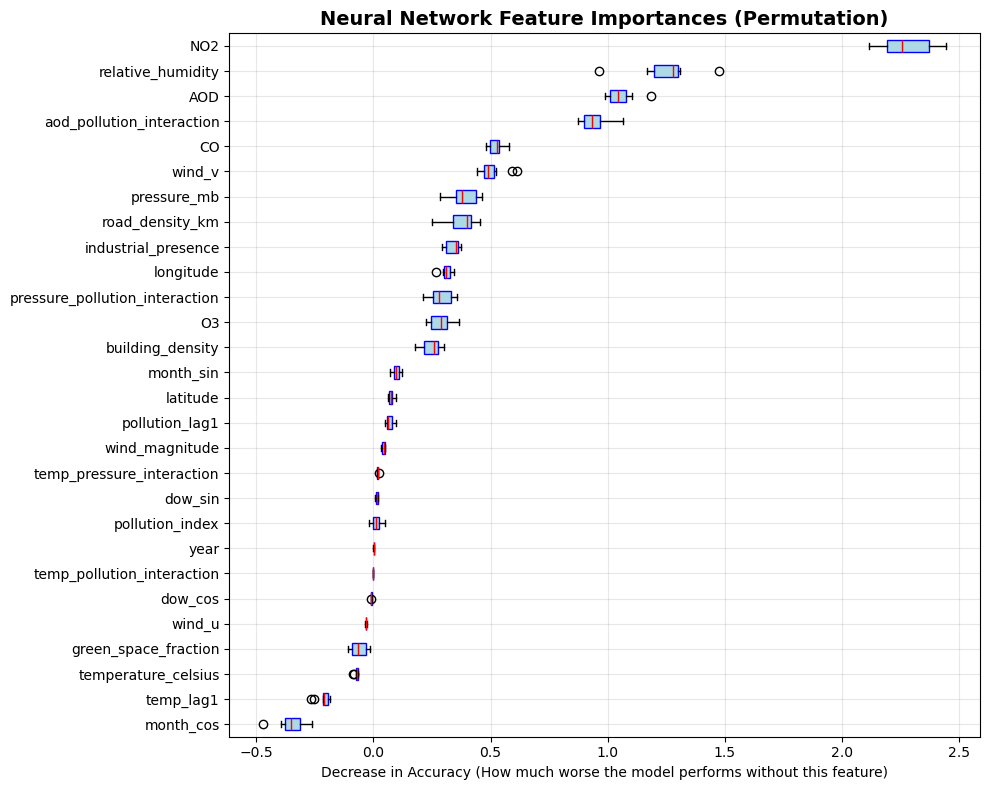

In [75]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

print("Calculating Permutation Feature Importance (this might take a few seconds)...")

# Calculate importance on the validation set
result = permutation_importance(
    final_model, 
    X_test, 
    y_test, 
    n_repeats=10,       # Shuffles each feature 10 times to get a stable average
    random_state=42, 
    n_jobs=-1,          # Uses all your CPU cores to make it fast
    scoring='neg_mean_squared_error' # We look at how much the error increases
)

# Sort the features by how important they are
sorted_idx = result.importances_mean.argsort()

# Create a nice plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=X_test.columns[sorted_idx],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='blue'),
    medianprops=dict(color='red')
)

ax.set_title("Neural Network Feature Importances (Permutation)", fontsize=14, fontweight='bold')
ax.set_xlabel("Decrease in Accuracy (How much worse the model performs without this feature)")
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig(model_dir / 'nn_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


- The result of the plot shows exactly why the neural network performance is not realy at its best since the pm25_lag1 dominates the other features and the models learned to use the previous value of the pm25_lag1 to predict the current one

In [76]:

# We use the 'result' object generated by the permutation_importance cell above.
mean_importances = result.importances_mean
# Some importances might be slightly negative due to random chance (meaning the model didn't use them). 
# We clip negatives to 0 so out percentages make mathematical sense.
positive_importances = np.maximum(mean_importances, 0)
# Calculate the percentages
total_importance = positive_importances.sum()
if total_importance > 0:
    percentages = (positive_importances / total_importance) * 100
else:
    percentages = np.zeros_like(positive_importances)
# Build a DataFrame for easy sorting and display
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Percentage (%)': percentages
})
# Sort from highest importance to lowest
importance_df = importance_df.sort_values(by='Percentage (%)', ascending=False).reset_index(drop=True)
# Print a nicely formatted table
print("FEATURE IMPORTANCE PERCENTAGES")
print("="*45)
for _, row in importance_df.iterrows():
    # Print out any feature that contributes at least 0.01%
    if row['Percentage (%)'] >= 0.01:
        print(f"{row['Feature']:<35} {row['Percentage (%)']:>6.2f}%")
print("="*45)
print(f"{'TOTAL':<35} 100.00%")

FEATURE IMPORTANCE PERCENTAGES
NO2                                  25.01%
relative_humidity                    13.75%
AOD                                  11.59%
aod_pollution_interaction            10.33%
CO                                    5.75%
wind_v                                5.54%
pressure_mb                           4.22%
road_density_km                       4.15%
industrial_presence                   3.72%
longitude                             3.42%
pressure_pollution_interaction        3.15%
O3                                    3.13%
building_density                      2.69%
month_sin                             1.06%
latitude                              0.83%
pollution_lag1                        0.74%
wind_magnitude                        0.46%
temp_pressure_interaction             0.20%
dow_sin                               0.15%
pollution_index                       0.10%
TOTAL                               100.00%


## 8. Save Model & Results

In [77]:
# Save model
joblib.dump(final_model, model_dir / 'best_pm25_mlp_model.pkl')
print(f"Model saved to {model_dir / 'best_pm25_mlp_model.pkl'}")

# Save results
results_df.to_csv(model_dir / 'model_performance.csv')
print(f"Results saved to {model_dir / 'model_performance.csv'}")

# Model info
n_params = sum(w.size for w in final_model.coefs_) + sum(b.size for b in final_model.intercepts_)
print(f"\nModel Summary:")
print(f"  Total parameters: {n_params:,}")
print(f"  Architecture: {final_model.hidden_layer_sizes}")
print(f"  Best CV RMSE: {study.best_value:.4f} μg/m³")
print(f"  Test RMSE: {results['Test']['RMSE']:.4f} μg/m³")
print(f"  Test R²: {results['Test']['R²']:.4f}")


Model saved to c:\Users\user\Desktop\3Y\S02\GP\project\pm25-air-quality\models\best_pm25_mlp_model.pkl
Results saved to c:\Users\user\Desktop\3Y\S02\GP\project\pm25-air-quality\models\model_performance.csv

Model Summary:
  Total parameters: 18,497
  Architecture: (64, 128, 64)
  Best CV RMSE: 14.5781 μg/m³
  Test RMSE: 6.7550 μg/m³
  Test R²: 0.1389
